# 1 - Modularização do Modelo Memory Polynomial

Transformar cada ramo de atraso e processamento do diagrama de blocos do modelo Memory Polynomial (MP), conforme ilustrado na Figura 10, em funções independentes. Cada função deve representar um termo de memória m, processando a envoltória complexa do sinal de entrada para calcular a contribuição polinomial individual de cada ramo antes da soma final.

In [1]:
from scipy.io import loadmat
import numpy as np


mat = loadmat('in_out_SBRT2_direto.mat')

in_data_ext = mat['in_extraction'].flatten()
out_data_ext = mat['out_extraction'].flatten()
in_data_val = mat['in_validation'].flatten()
out_data_val = mat['out_validation'].flatten()


In [2]:
def bloco_memoria_mp(x_delay, coef_m, ordem):
    """
    Implementa o bloco:
        sum_{p=1}^P b_{p,m} * x(n-m) * |x(n-m)|^(2*(p-1))

    x_delay : x(n-m) (vetor complexo)
    coef_m  : coeficientes complexos desse atraso (tamanho = ordem)
    ordem   : ordem do polinômio
    """
    y_m = np.zeros_like(x_delay, dtype=complex)

    for p in range(1, ordem + 1):
        y_m += coef_m[p-1] * x_delay * np.abs(x_delay)**(2*(p-1))

    return y_m


def mp_model(x_in, coef, ordem, memoria):
    """
    Modelo Memory Polynomial estruturado por blocos

    coef : vetor complexo organizado como:
           [b_{1,0}, ..., b_{P,0},
            b_{1,1}, ..., b_{P,1},
            ...
            b_{1,M}, ..., b_{P,M}]
    """
    N = len(x_in)
    y_est = np.zeros(N, dtype=complex)

    idx = 0
    for m in range(memoria + 1):
        # Atraso
        x_delay = np.roll(x_in, m)

        # Coeficientes desse bloco de memória
        coef_m = coef[idx:idx + ordem]
        idx += ordem

        # Bloco do somatório (figura que você mostrou)
        y_est += bloco_memoria_mp(x_delay, coef_m, ordem)

    return y_est

def erro_mp_complex_blocos(params, x_in, y_out, ordem, memoria):
    """
    Erro do modelo MP estruturado por blocos
    """
    C = len(params) // 2
    coef = params[:C] + 1j * params[C:]

    y_est = mp_model(x_in, coef, ordem, memoria)
    erro = y_out - y_est

    return np.abs(erro) 


In [3]:
from scipy.optimize import least_squares

ordem = 5
memoria = 2
num_coef = ordem * (memoria+1)

# Vetor inicial: separar parte real e imaginária
x0 = np.zeros(2*num_coef)

res = least_squares(
    erro_mp_complex_blocos,
    x0,
    args=(in_data_ext, out_data_ext, ordem, memoria),
    verbose=2
)

coef_otimo = res.x[:num_coef] + 1j*res.x[num_coef:]
print("Coeficientes complexos otimizados:", coef_otimo)

# Calcular MSE na validação
erro_val = erro_mp_complex_blocos(res.x, in_data_val, out_data_val, ordem, memoria)
mse_val = np.mean(erro_val**2)
print("MSE validação:", mse_val)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.8318e+02                                    2.69e+03    
       1              3         1.0603e+02      7.77e+02       2.50e-01       4.80e+02    
       2              4         1.3536e+01      9.25e+01       5.00e-01       2.18e+02    
       3              5         4.8673e+00      8.67e+00       1.00e+00       1.20e+02    
       4              6         3.6599e+00      1.21e+00       1.00e+00       5.38e+01    
       5              8         3.5783e+00      8.16e-02       2.50e-01       3.89e+01    
       6              9         2.7286e+00      8.50e-01       6.25e-02       5.12e+01    
       7             10         2.5129e+00      2.16e-01       6.25e-02       4.55e+01    
       8             11         2.3834e+00      1.29e-01       1.56e-02       4.73e+01    
       9             12         2.2404e+00      1.43e-01       3.91e-03       3.26e+01    

valor de NMSE: -26.69310673592981


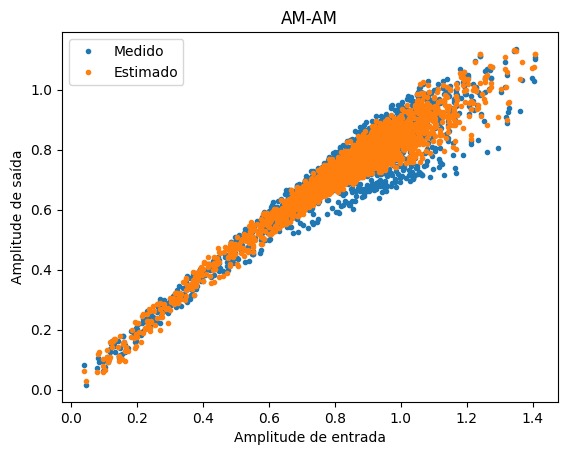

In [4]:
import matplotlib.pyplot as plt
nmse_calculo = lambda predicted_val, data_out:10 * np.log10(np.mean(np.abs(data_out - predicted_val) ** 2) / np.mean(np.abs(data_out) ** 2))

def mp(P, M, xn, coef):
    L = xn.shape[0]
    y_est = np.zeros(L, dtype=complex)

    idx = 0
    for k in range(M+1):
        xk = np.roll(xn, k)
        for p in range(1, P+1):
            y_est += coef[idx] * (xk * np.abs(xk)**((p-1)*2))
            idx += 1
    return y_est


predicted_val = mp(ordem, memoria, in_data_val, coef_otimo)

nmse_calculado = nmse_calculo(predicted_val[memoria:], out_data_val[memoria:])
print(f"valor de NMSE: {nmse_calculado}")
plt.figure()
plt.plot(np.abs(in_data_val[memoria:]), np.abs(out_data_val[memoria:]), '.', label='Medido')
plt.plot(np.abs(in_data_val[memoria:]), np.abs(predicted_val[memoria:]), '.', label='Estimado')
plt.xlabel('Amplitude de entrada')
plt.ylabel('Amplitude de saída')
plt.title('AM-AM')
plt.legend()

plt.show()